In [292]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [294]:
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
]))
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

print(train_data.data.shape)
print(train_data.classes)

Files already downloaded and verified
Files already downloaded and verified
(50000, 32, 32, 3)
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [295]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(800, len(train_data.classes)),
        )
        self.layers = nn.Sequential(feature_extractor, classifier)

    def forward(self, x):
        return self.layers(x)

model = CNN().to(device)
    

In [297]:
from torchsummary import summary
summary(model, (3, 32, 32), device=str(device), batch_size=64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [64, 16, 34, 34]             448
       BatchNorm2d-2           [64, 16, 34, 34]              32
              ReLU-3           [64, 16, 34, 34]               0
         MaxPool2d-4           [64, 16, 17, 17]               0
            Conv2d-5           [64, 32, 19, 19]           4,640
       BatchNorm2d-6           [64, 32, 19, 19]              64
              ReLU-7           [64, 32, 19, 19]               0
         MaxPool2d-8             [64, 32, 9, 9]               0
            Conv2d-9           [64, 32, 11, 11]           9,248
      BatchNorm2d-10           [64, 32, 11, 11]              64
             ReLU-11           [64, 32, 11, 11]               0
        MaxPool2d-12             [64, 32, 5, 5]               0
          Flatten-13                  [64, 800]               0
          Dropout-14                  [

In [ ]:
def get_output_size(W, kernel_size, stride, padding, num_filters, H=None):
    if H is None:
        H = W
    w_out = (W - kernel_size + 2 * padding) // stride + 1
    h_out = (W - kernel_size + 2 * padding) // stride + 1
    print((w_out, h_out, num_filters))

get_output_size(28, kernel_size=1, stride=1, padding=0, num_filters=64)     # Conv2d
get_output_size(28, kernel_size=3, stride=1, padding=1, num_filters=128)    # Conv2d
get_output_size(28, kernel_size=5, stride=1, padding=2, num_filters=32)     # Conv2d


(28, 28, 64)
(28, 28, 128)
(28, 28, 32)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=2e-3,                 # Adam default is 1e-3
    betas=(0.9, 0.999),      # default momentum terms
    eps=1e-8,                # numerical stability term
    weight_decay=1e-4        # L2 regularization, if you still want it
)

In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

def train_and_plot_inline(model, train_loader, test_loader, train_data, test_data, device, epochs=20):
    """
    Trains the model and updates inline charts at each epoch 
    showing train vs test loss and accuracy with grid lines and markers.
    """
    # Lists to store metrics
    epochs_list = []
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    for epoch in range(1, epochs + 1):
        # Before you start training/testing
        torch.cuda.reset_peak_memory_stats(device)   # clear previous stats

        # Train
        model.train()
        total_loss, correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / len(train_data)

        # Test
        model.eval()
        with torch.no_grad():
            total_loss, correct = 0.0, 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
            avg_test_loss = total_loss / len(test_loader)
            test_acc = correct / len(test_data)

        # Record
        epochs_list.append(epoch)
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        test_losses.append(avg_test_loss)
        test_accs.append(test_acc)

        # Clear and redraw
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        print(f"Epoch {epoch}/{epochs} - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc:.4f}")
        
        # Right after your loop:
        allocated = torch.cuda.memory_allocated(device)       # current usage
        reserved  = torch.cuda.memory_reserved(device)        # total reserved by caching allocator
        peak      = torch.cuda.max_memory_allocated(device)   # peak usage during the run

        print(f"Current GPU memory allocated: {allocated/1024**2:.1f} MB")
        print(f"Current GPU memory reserved:  {reserved/1024**2:.1f} MB")
        print(f"Peak GPU memory usage:         {peak/1024**2:.1f} MB")
            
        # Train plot with grid and markers
        axes[0].plot(epochs_list, [acc * 100 for acc in train_accs], label='Train', marker='o')
        axes[0].plot(epochs_list, [acc * 100 for acc in test_accs], label='Test', marker='x')
        axes[0].set_title('Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()
        axes[0].grid(True)

        # Test plot with grid and markers
        axes[1].plot(epochs_list, train_losses, label='Train', marker='o')
        axes[1].plot(epochs_list, test_losses, label='Test', marker='x')
        axes[1].set_title('Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()


Epoch 50/50 - Train Loss: 0.6622, Train Acc: 0.7693, Test Loss: 0.7081, Test Acc: 0.7580
Current GPU memory allocated: 66.3 MB
Current GPU memory reserved:  698.0 MB
Peak GPU memory usage:         117.4 MB


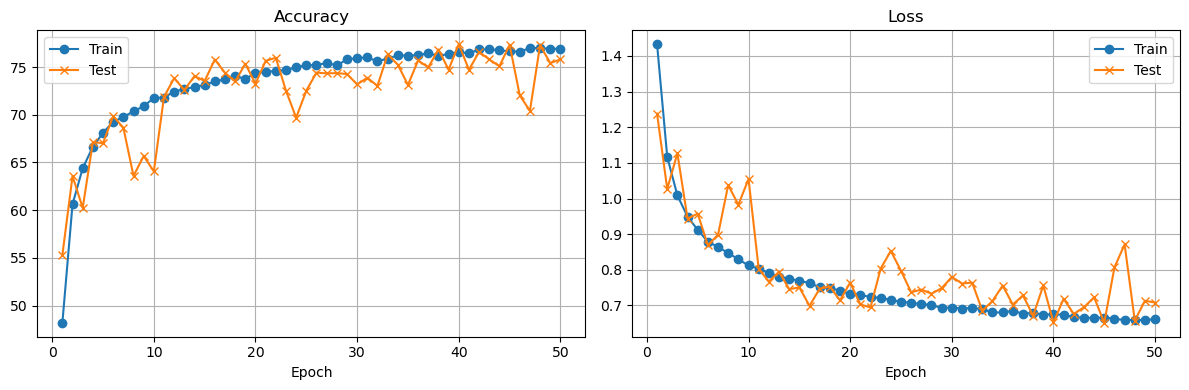

In [ ]:
train_and_plot_inline(model, train_loader, test_loader, train_data, test_data, device, epochs=50)
